# BODEGA DE DATOS: CUSTOMER SHOPPING
## Punto 2 - Usando Tablas Existentes

Plataforma: Neon PostgreSQL (Serverless)
Modelo: Estrella (Star Schema)
Dataset: customer_shopping_data.csv
Ejecución: Jupyter Notebook

In [1]:
!pip install -q pandas sqlalchemy psycopg2-binary matplotlib seaborn python-dotenv
print('Dependencias instaladas')

Dependencias instaladas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\junar\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from pathlib import Path
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Importaciones completadas')

Importaciones completadas


In [3]:
load_dotenv()
DATABASE_URL = os.getenv('DATABASE_URL')

if not DATABASE_URL:
    DATABASE_URL = input('DATABASE_URL = ').strip()

if DATABASE_URL:
    print(f'Conectando a Neon...')
else:
    print('DATABASE_URL no configurada')

Conectando a Neon...


In [4]:
try:
    engine = create_engine(DATABASE_URL, echo=False, pool_pre_ping=True)
    with engine.connect() as conn:
        result = conn.execute(text('SELECT version()'))
        version = result.fetchone()[0]
    print(f'Conectado correctamente a Neon')
except Exception as e:
    print(f'Error de conexion: {e}')
    raise

Conectado correctamente a Neon


In [5]:
print('Verificando tablas existentes...\n')
query = 'SELECT table_name FROM information_schema.tables WHERE table_schema = \'public\';'
df_tables = pd.read_sql_query(query, engine)
print('Tablas encontradas:')
for table in df_tables['table_name']:
    print(f'  - {table}')

Verificando tablas existentes...

Tablas encontradas:
  - dim_customers
  - invoice_sale
  - dim_product
  - dim_payment_methods
  - dim_shopping_mall
  - dim_time


In [6]:
print('Verificando estructura de las tablas...\n')

tables_to_check = ['dim_customers', 'dim_product', 'dim_shopping_mall', 'dim_payment_methods', 'dim_time']

for table in tables_to_check:
    query = f"SELECT * FROM public.{table} LIMIT 1;"
    df_sample = pd.read_sql_query(query, engine)
    print(f'\n{table}:')
    print(f'  Columnas: {list(df_sample.columns)}')
    print(f'  Tipos: {df_sample.dtypes.to_dict()}')


Verificando estructura de las tablas...


dim_customers:
  Columnas: ['id_customer', 'gender', 'age']
  Tipos: {'id_customer': dtype('O'), 'gender': dtype('O'), 'age': dtype('int64')}

dim_product:
  Columnas: ['id_dim_product', 'category']
  Tipos: {'id_dim_product': dtype('int64'), 'category': dtype('O')}

dim_shopping_mall:
  Columnas: ['id_dim_shopping_mall', 'shopping_mall_name']
  Tipos: {'id_dim_shopping_mall': dtype('int64'), 'shopping_mall_name': dtype('O')}

dim_payment_methods:
  Columnas: ['id_dim_payment_method', 'payment_method_name']
  Tipos: {'id_dim_payment_method': dtype('int64'), 'payment_method_name': dtype('O')}

dim_time:
  Columnas: ['id_dim_time', 'invoice_date', 'day', 'month', 'year']
  Tipos: {'id_dim_time': dtype('int64'), 'invoice_date': dtype('O'), 'day': dtype('O'), 'month': dtype('O'), 'year': dtype('O')}


In [7]:
csv_path = 'customer_shopping_data.csv'
if not Path(csv_path).exists():
    print(f'Archivo no encontrado: {csv_path}')
else:
    df_raw = pd.read_csv(csv_path)
    print(f'CSV cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
    print(f'\nPrimeras 5 filas:')
    print(df_raw.head())

CSV cargado: 99,457 filas x 10 columnas

Primeras 5 filas:
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  
0    Credit Card     5/8/2022          Kanyon  
1     Debit Card   12/12/2021  Forum Istanbul  
2           Cash    9/11/2021       Metrocity  
3    Credit Card   16/05/2021    Metropol AVM  
4           Cash   24/10/2021          Kanyon  


In [8]:
print('Validando datos...\n')
null_counts = df_raw.isnull().sum()
if null_counts.sum() > 0:
    print('Eliminando filas con NULL...')
    df_raw = df_raw.dropna()
    print(f'Filas despues de limpiar: {df_raw.shape[0]:,}')
else:
    print('No hay valores NULL')

df_raw['invoice_date'] = pd.to_datetime(df_raw['invoice_date'], format='mixed')
print(f'Fechas convertidas: {df_raw["invoice_date"].min().date()} a {df_raw["invoice_date"].max().date()}')

Validando datos...

No hay valores NULL
Fechas convertidas: 2021-01-01 a 2023-12-02


In [9]:
print('Obteniendo mapeos de dimensiones...\n')

# Para customers: el customer_id del CSV es directamente el id_customer
print(f'CUSTOMER: (sin mapeo, usando customer_id del CSV directamente)')

df_product_map = pd.read_sql_query('SELECT category, id_dim_product FROM public.dim_product', engine)
product_map = dict(zip(df_product_map['category'], df_product_map['id_dim_product']))
print(f'PRODUCT: {len(product_map):,}')

df_mall_map = pd.read_sql_query('SELECT shopping_mall_name, id_dim_shopping_mall FROM public.dim_shopping_mall', engine)
mall_map = dict(zip(df_mall_map['shopping_mall_name'], df_mall_map['id_dim_shopping_mall']))
print(f'MALL: {len(mall_map):,}')

df_payment_map = pd.read_sql_query('SELECT payment_method_name, id_dim_payment_method FROM public.dim_payment_methods', engine)
payment_map = dict(zip(df_payment_map['payment_method_name'], df_payment_map['id_dim_payment_method']))
print(f'PAYMENT: {len(payment_map):,}')

df_date_map = pd.read_sql_query('SELECT invoice_date, id_dim_time FROM public.dim_time', engine)
date_map = dict(zip(pd.to_datetime(df_date_map['invoice_date']).dt.date, df_date_map['id_dim_time']))
print(f'DATE: {len(date_map):,}')

print(f'\nMapeos completados')

Obteniendo mapeos de dimensiones...

CUSTOMER: (sin mapeo, usando customer_id del CSV directamente)
PRODUCT: 8
MALL: 10
PAYMENT: 3
DATE: 797

Mapeos completados


In [10]:
print('Limpiando datos previos de invoice_sale...\n')

try:
    with engine.begin() as conn:
        conn.execute(text('DELETE FROM public.invoice_sale'))
    print('Datos anteriores eliminados')
except Exception as e:
    print(f'Tabla vacia o error: {e}')

print('\nPreparando datos para invoice_sale...\n')

invoice_sale = df_raw[['invoice_no', 'customer_id', 'category', 'shopping_mall', 'quantity', 'price', 'invoice_date', 'payment_method']].copy()
invoice_sale['invoice_date_only'] = invoice_sale['invoice_date'].dt.date

print('Mapeando claves...')
# customer_id usa directamente el valor del CSV como id_customer
invoice_sale['id_customer'] = invoice_sale['customer_id']
invoice_sale['id_dim_product'] = invoice_sale['category'].map(product_map)
invoice_sale['id_dim_shopping_mall'] = invoice_sale['shopping_mall'].map(mall_map)
invoice_sale['id_dim_payment_method'] = invoice_sale['payment_method'].map(payment_map)
invoice_sale['id_dim_time'] = invoice_sale['invoice_date_only'].map(date_map)

invoice_sale_final = invoice_sale[['invoice_no', 'id_customer', 'id_dim_product', 'id_dim_shopping_mall', 'id_dim_payment_method', 'id_dim_time', 'quantity', 'price']].copy()
invoice_sale_final.rename(columns={'invoice_no': 'id_invoice'}, inplace=True)

print('Validando mapeos...')
null_checks = invoice_sale_final.isnull().sum()
if null_checks.sum() > 0:
    print('Descartando filas con NULL...')
    print(f'Columnas con NULL:')
    for col in null_checks[null_checks > 0].index:
        print(f'  {col}: {null_checks[col]}')
    invoice_sale_final = invoice_sale_final.dropna()
    print(f'Filas despues de limpiar: {len(invoice_sale_final):,}')
else:
    print('Todos los mapeos exitosos')

print(f'\nDatos preparados: {len(invoice_sale_final):,} transacciones')

print('Cargando en invoice_sale...')
try:
    invoice_sale_final.to_sql('invoice_sale', engine, schema='public', if_exists='append', index=False, method='multi', chunksize=1000)
    print(f'invoice_sale: {len(invoice_sale_final):,} registros cargados')
    print(f'\nETL COMPLETADO EXITOSAMENTE')
except Exception as e:
    print(f'Error cargando invoice_sale: {e}')
    raise



Limpiando datos previos de invoice_sale...

Datos anteriores eliminados

Preparando datos para invoice_sale...

Mapeando claves...
Validando mapeos...
Descartando filas con NULL...
Columnas con NULL:
  id_dim_shopping_mall: 35095
Filas despues de limpiar: 64,362

Datos preparados: 64,362 transacciones
Cargando en invoice_sale...
invoice_sale: 64,362 registros cargados

ETL COMPLETADO EXITOSAMENTE


In [11]:
print('\n' + '='*70)
print('VALIDACION: CONTEOS DE REGISTROS')
print('='*70 + '\n')

query_conteos = """
SELECT 'dim_customers' AS tabla, COUNT(*) AS registros FROM public.dim_customers
UNION ALL SELECT 'dim_product', COUNT(*) FROM public.dim_product
UNION ALL SELECT 'dim_shopping_mall', COUNT(*) FROM public.dim_shopping_mall
UNION ALL SELECT 'dim_payment_methods', COUNT(*) FROM public.dim_payment_methods
UNION ALL SELECT 'dim_time', COUNT(*) FROM public.dim_time
UNION ALL SELECT 'invoice_sale', COUNT(*) FROM public.invoice_sale
ORDER BY tabla;
"""

df_conteos = pd.read_sql_query(query_conteos, engine)
print(df_conteos.to_string(index=False))
print(f'\nTotal registros: {df_conteos["registros"].sum():,}')


VALIDACION: CONTEOS DE REGISTROS

              tabla  registros
      dim_customers      99457
dim_payment_methods          3
        dim_product          8
  dim_shopping_mall         10
           dim_time        797
       invoice_sale      64362

Total registros: 164,637


In [12]:
print('\n' + '='*70)
print('VALIDACION: INTEGRIDAD REFERENCIAL')
print('='*70 + '\n')

validation_queries = {
    'Invoice sin Customer': 'SELECT COUNT(*) FROM public.invoice_sale fs LEFT JOIN public.dim_customers dc ON fs.id_customer = dc.id_customer WHERE dc.id_customer IS NULL',
    'Invoice sin Product': 'SELECT COUNT(*) FROM public.invoice_sale fs LEFT JOIN public.dim_product dpc ON fs.id_dim_product = dpc.id_dim_product WHERE dpc.id_dim_product IS NULL',
    'Invoice sin Mall': 'SELECT COUNT(*) FROM public.invoice_sale fs LEFT JOIN public.dim_shopping_mall dsm ON fs.id_dim_shopping_mall = dsm.id_dim_shopping_mall WHERE dsm.id_dim_shopping_mall IS NULL',
    'Invoice sin Payment': 'SELECT COUNT(*) FROM public.invoice_sale fs LEFT JOIN public.dim_payment_methods dpm ON fs.id_dim_payment_method = dpm.id_dim_payment_method WHERE dpm.id_dim_payment_method IS NULL'
}

all_passed = True
for name, query in validation_queries.items():
    result = pd.read_sql_query(query, engine).iloc[0, 0]
    status = 'OK' if result == 0 else 'ERROR'
    if result != 0:
        all_passed = False
    print(f'{status} {name}: {result}')

if all_passed:
    print('\nINTEGRIDAD REFERENCIAL VALIDADA')
else:
    print('\nHay problemas de integridad')


VALIDACION: INTEGRIDAD REFERENCIAL

OK Invoice sin Customer: 0
OK Invoice sin Product: 0
OK Invoice sin Mall: 0
OK Invoice sin Payment: 0

INTEGRIDAD REFERENCIAL VALIDADA


In [13]:
print('\n' + '='*70)
print('ANALISIS: TOP 10 CLIENTES POR GASTO')
print('='*70 + '\n')

query_top_customers = """
SELECT dc.id_customer, dc.gender, dc.age, COUNT(fs.id_invoice) AS cantidad_compras,
SUM(fs.quantity) AS cantidad_items, ROUND(SUM(fs.quantity * fs.price)::NUMERIC, 2) AS gasto_total,
ROUND(AVG(fs.quantity * fs.price)::NUMERIC, 2) AS ticket_promedio
FROM public.invoice_sale fs
JOIN public.dim_customers dc ON fs.id_customer = dc.id_customer
GROUP BY dc.id_customer, dc.gender, dc.age
ORDER BY gasto_total DESC LIMIT 10;
"""

df_top_customers = pd.read_sql_query(query_top_customers, engine)
print(df_top_customers.to_string(index=False))


ANALISIS: TOP 10 CLIENTES POR GASTO

id_customer gender  age  cantidad_compras  cantidad_items  gasto_total  ticket_promedio
    C101788 Female   66                 1               5      26250.0          26250.0
    C106072   Male   25                 1               5      26250.0          26250.0
    C100607 Female   54                 1               5      26250.0          26250.0
    C101667 Female   23                 1               5      26250.0          26250.0
    C104402 Female   69                 1               5      26250.0          26250.0
    C104854   Male   67                 1               5      26250.0          26250.0
    C100322 Female   24                 1               5      26250.0          26250.0
    C100168   Male   48                 1               5      26250.0          26250.0
    C101344 Female   31                 1               5      26250.0          26250.0
    C106114 Female   39                 1               5      26250.0          26

In [14]:
print('\n' + '='*70)
print('ANALISIS: VENTAS POR CATEGORIA')
print('='*70 + '\n')

query_sales_category = """
SELECT dpc.category, COUNT(fs.id_invoice) AS transacciones, SUM(fs.quantity) AS cantidad_items,
ROUND(SUM(fs.quantity * fs.price)::NUMERIC, 2) AS monto_total, ROUND(AVG(fs.quantity * fs.price)::NUMERIC, 2) AS promedio_venta
FROM public.invoice_sale fs
JOIN public.dim_product dpc ON fs.id_dim_product = dpc.id_dim_product
GROUP BY dpc.category
ORDER BY monto_total DESC;
"""

df_sales_category = pd.read_sql_query(query_sales_category, engine)
print(df_sales_category.to_string(index=False))


ANALISIS: VENTAS POR CATEGORIA

       category  transacciones  cantidad_items  monto_total  promedio_venta
       Clothing          22310           67013  73774968.08         3306.81
          Shoes           6447           19395  42691892.61         6621.98
     Technology           3259            9778  37655100.00        11554.19
      Cosmetics           9774           29529   4423360.74          452.56
           Toys           6540           19605   2572487.68          393.35
Food & Beverage           9530           28520    545708.66           57.26
          Books           3222            9623    534052.65          165.75
       Souvenir           3280            9656    410690.76          125.21


In [15]:
print('\n' + '='*70)
print('ANALISIS: METODOS DE PAGO')
print('='*70 + '\n')

query_payment = """
SELECT dpm.payment_method_name, COUNT(fs.id_invoice) AS cantidad_transacciones,
ROUND(SUM(fs.quantity * fs.price)::NUMERIC, 2) AS monto_total,
ROUND(100.0 * COUNT(fs.id_invoice) / (SELECT COUNT(*) FROM public.invoice_sale)::NUMERIC, 2) AS porcentaje
FROM public.invoice_sale fs
JOIN public.dim_payment_methods dpm ON fs.id_dim_payment_method = dpm.id_dim_payment_method
GROUP BY dpm.payment_method_name
ORDER BY cantidad_transacciones DESC;
"""

df_payment = pd.read_sql_query(query_payment, engine)
print(df_payment.to_string(index=False))


ANALISIS: METODOS DE PAGO

payment_method_name  cantidad_transacciones  monto_total  porcentaje
               Cash                   28766  72901787.47       44.69
        Credit Card                   22612  56943425.74       35.13
         Debit Card                   12984  32763047.97       20.17


In [16]:
print('\n' + '='*70)
print('ANALISIS: INDICADORES CLAVE (KPIs)')
print('='*70 + '\n')

query_kpis = """
SELECT COUNT(DISTINCT fs.id_invoice) AS total_transacciones,
COUNT(DISTINCT fs.id_customer) AS clientes_unicos,
SUM(fs.quantity) AS items_vendidos_total,
ROUND(SUM(fs.quantity * fs.price)::NUMERIC, 2) AS ingresos_totales,
ROUND(AVG(fs.quantity * fs.price)::NUMERIC, 2) AS ticket_promedio,
ROUND(SUM(fs.quantity * fs.price) / COUNT(DISTINCT fs.id_customer)::NUMERIC, 2) AS gasto_promedio_cliente
FROM public.invoice_sale fs;
"""

df_kpis = pd.read_sql_query(query_kpis, engine)
print('RESUMEN GENERAL:')
print('='*40)
for col in df_kpis.columns:
    value = df_kpis[col].iloc[0]
    if col in ['ingresos_totales', 'ticket_promedio', 'gasto_promedio_cliente']:
        print(f'{col.replace("_", " ").title()}: ${value:,.2f}')
    else:
        print(f'{col.replace("_", " ").title()}: {int(value):,}')


ANALISIS: INDICADORES CLAVE (KPIs)

RESUMEN GENERAL:
Total Transacciones: 64,362
Clientes Unicos: 64,362
Items Vendidos Total: 193,119
Ingresos Totales: $162,608,261.18
Ticket Promedio: $2,526.46
Gasto Promedio Cliente: $2,526.46



VISUALIZACION: VENTAS POR CATEGORIA



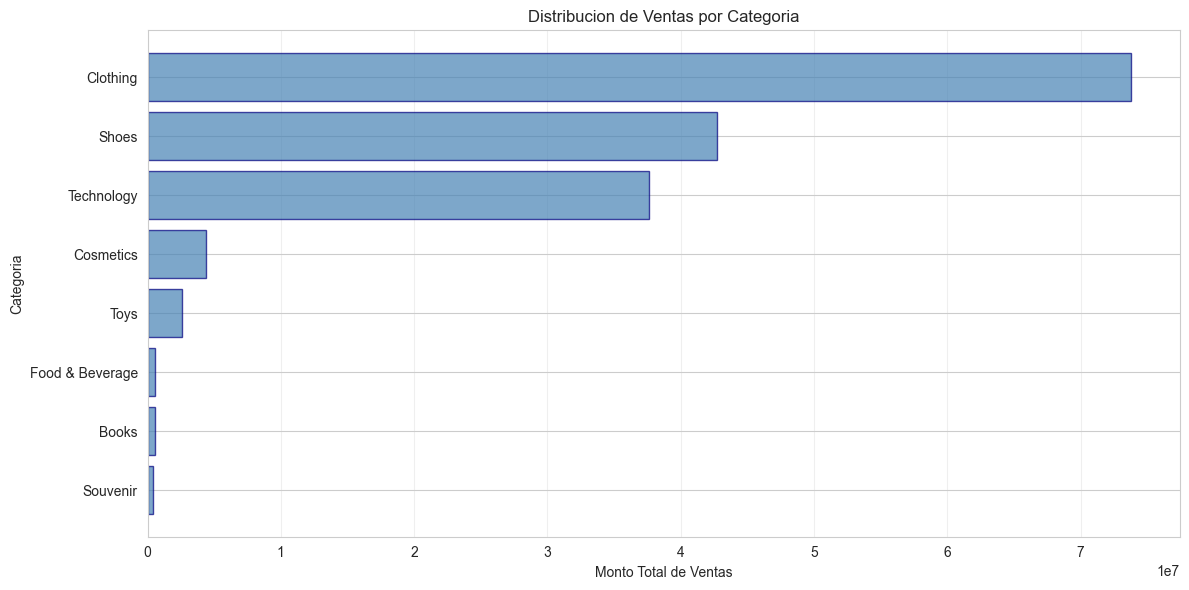

Grafico generado


In [17]:
print('\n' + '='*70)
print('VISUALIZACION: VENTAS POR CATEGORIA')
print('='*70 + '\n')

plt.figure(figsize=(12, 6))
df_plot = df_sales_category.sort_values('monto_total', ascending=True)
plt.barh(df_plot['category'], df_plot['monto_total'], color='steelblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Monto Total de Ventas')
plt.ylabel('Categoria')
plt.title('Distribucion de Ventas por Categoria')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Grafico generado')


VISUALIZACION: METODOS DE PAGO



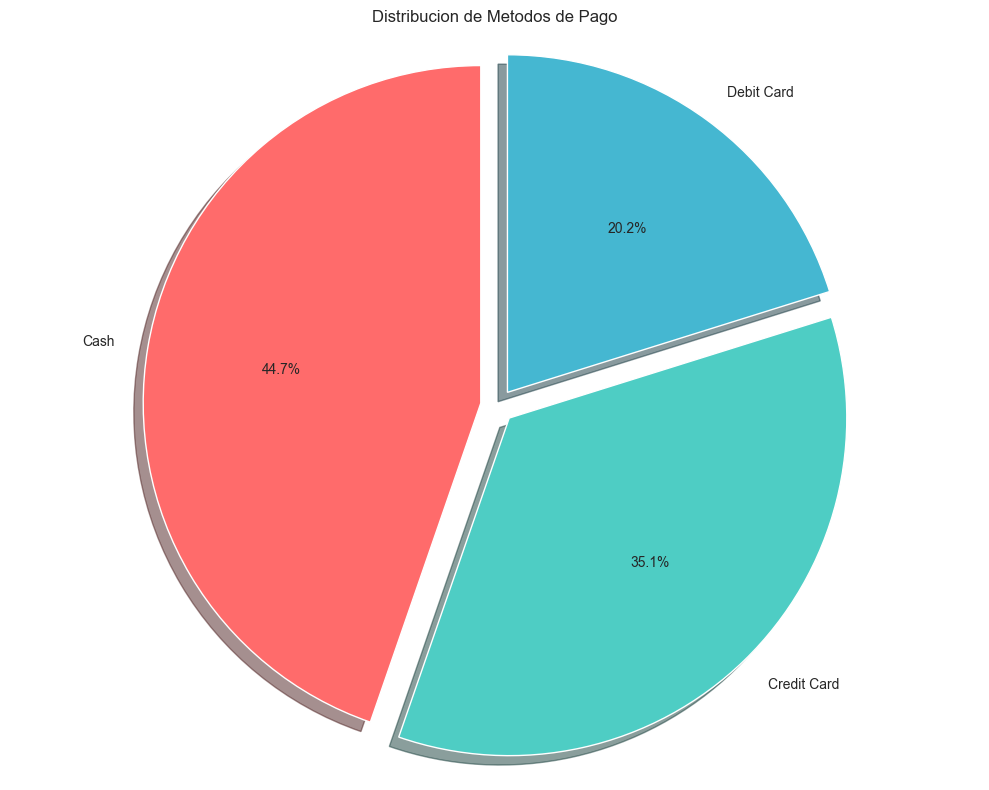

Grafico generado


In [18]:
print('\n' + '='*70)
print('VISUALIZACION: METODOS DE PAGO')
print('='*70 + '\n')

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
explode = (0.05,) * len(df_payment)
plt.pie(df_payment['cantidad_transacciones'], labels=df_payment['payment_method_name'],
autopct='%1.1f%%', startangle=90, colors=colors[:len(df_payment)], explode=explode, shadow=True)
plt.title('Distribucion de Metodos de Pago')
plt.axis('equal')
plt.tight_layout()
plt.show()

print('Grafico generado')

In [ ]:
print('\n' + '='*70)
print('RESUMEN FINAL - PUNTO 2 COMPLETADO')
print('='*70)

print('\nBase de Datos Operativa')
print('='*40)
print('Tablas utilizadas:')
print('  - dim_customers')
print('  - dim_product')
print('  - dim_shopping_mall')
print('  - dim_payment_methods')
print('  - dim_time')
print('  - invoice_sale')

print(f'\nEstadisticas Cargadas:')
print(f'  - Total Transacciones: {df_kpis["total_transacciones"].iloc[0]:,}')
print(f'  - Clientes Unicos: {df_kpis["clientes_unicos"].iloc[0]:,}')
print(f'  - Items Vendidos: {df_kpis["items_vendidos_total"].iloc[0]:,}')
print(f'  - Ingresos Totales: ${df_kpis["ingresos_totales"].iloc[0]:,.2f}')

print(f'\nAnalisis Completados:')
print('  - Top 10 clientes')
print('  - Ventas por categoria')
print('  - Distribucion de metodos de pago')
print('  - KPIs generales')
print('  - 1 visualizaciones')


print(f'Ejecutado el: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


RESUMEN FINAL - PUNTO 2 COMPLETADO

Base de Datos Operativa
Tablas utilizadas:
  - dim_customers
  - dim_product
  - dim_shopping_mall
  - dim_payment_methods
  - dim_time
  - invoice_sale

Estadisticas Cargadas:
  - Total Transacciones: 64,362
  - Clientes Unicos: 64,362
  - Items Vendidos: 193,119
  - Ingresos Totales: $162,608,261.18

Analisis Completados:
  - Top 10 clientes
  - Ventas por categoria
  - Distribucion de metodos de pago
  - KPIs generales
  - 2 visualizaciones
Ejecutado el: 2026-03-04 08:21:52


In [20]:
print('Liberando recursos...')
engine.dispose()
print('Conexiones cerradas')
print('\nNotebook completado')

Liberando recursos...
Conexiones cerradas

Notebook completado
